# Twin‑Prime Lattice Engine 🧮
This notebook recreates the **Twin‑Prime Lattice Engine** in an interactive form.

* **Purpose**  Detect square‑shell spacings  Δ(n)=2n+1 and flag *twin‑prime shells* where both Δ(n) **and** Δ(n)+2 are prime.
* **Outputs**  ASCII table, CSV export, optional Matplotlib scatter plot.
* **Usage**   Run all cells, then adjust `MAX_N` or toggle plotting.


In [1]:

import math, csv
from dataclasses import dataclass
from pathlib import Path
from typing import List

_SMALL_PRIMES = (2,3,5,7,11,13,17,19,23,29,31,37)
def is_prime(n:int)->bool:
    if n<2:
        return False
    for p in _SMALL_PRIMES:
        if n%p==0:
            return n==p
    limit=int(math.isqrt(n))+1
    k=1
    while (step:=6*k-1)<=limit:
        if n%step==0 or n%(step+2)==0:
            return False
        k+=1
    return True

@dataclass
class Shell:
    n:int
    n2:int
    delta:int
    twin:bool
    def as_row(self):
        return (self.n,self.n2,self.delta,"Twin" if self.twin else "-")

def analyse(max_n:int=200)->List[Shell]:
    rows=[]
    for n in range(1,max_n+1):
        d=2*n+1
        rows.append(Shell(n,n*n,d,is_prime(d) and is_prime(d+2)))
    return rows

def ascii_table(rows):
    header=("n","n²","Δ","Twin?")
    widths=(5,10,6,6)
    fmt=lambda x,w:str(x).rjust(w)
    hdr=" ".join(fmt(h,w) for h,w in zip(header,widths))
    bar="-"*len(hdr)
    body="\n".join(" ".join(fmt(v,w) for v,w in zip(r.as_row(),widths)) for r in rows)
    return f"{hdr}\n{bar}\n{body}"

def export_csv(rows,path="twin_prime_shells.csv"):
    with open(path,"w",newline="") as fh:
        writer=csv.writer(fh)
        writer.writerow(("n","n2","delta","twin")) 
        for r in rows:
            writer.writerow(r.as_row())
    return Path(path).resolve()

def plot_shells(rows):
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("matplotlib missing – skipping plot")
        return
    xs=[r.n for r in rows]
    ys=[r.delta for r in rows]
    colors=['red' if r.twin else 'grey' for r in rows]
    plt.figure(figsize=(10,6),dpi=110)
    plt.scatter(xs,ys,c=colors,s=20)
    plt.xlabel("grid side n")
    plt.ylabel("Δ(n)=2n+1")
    plt.title("Twin‑prime shells (red) in n² lattice")
    plt.grid(True,ls=":",lw=0.4)
    plt.show()


    n         n²      Δ  Twin?
------------------------------
    1          1      3   Twin
    2          4      5   Twin
    3          9      7      -
    4         16      9      -
    5         25     11   Twin
    6         36     13      -
    7         49     15      -
    8         64     17   Twin
    9         81     19      -
   10        100     21      -
   11        121     23      -
   12        144     25      -
   13        169     27      -
   14        196     29   Twin
   15        225     31      -
   16        256     33      -
   17        289     35      -
   18        324     37      -
   19        361     39      -
   20        400     41   Twin
   21        441     43      -
   22        484     45      -
   23        529     47      -
   24        576     49      -
   25        625     51      -
   26        676     53      -
   27        729     55      -
   28        784     57      -
   29        841     59   Twin
   30        900     61      -
   31   

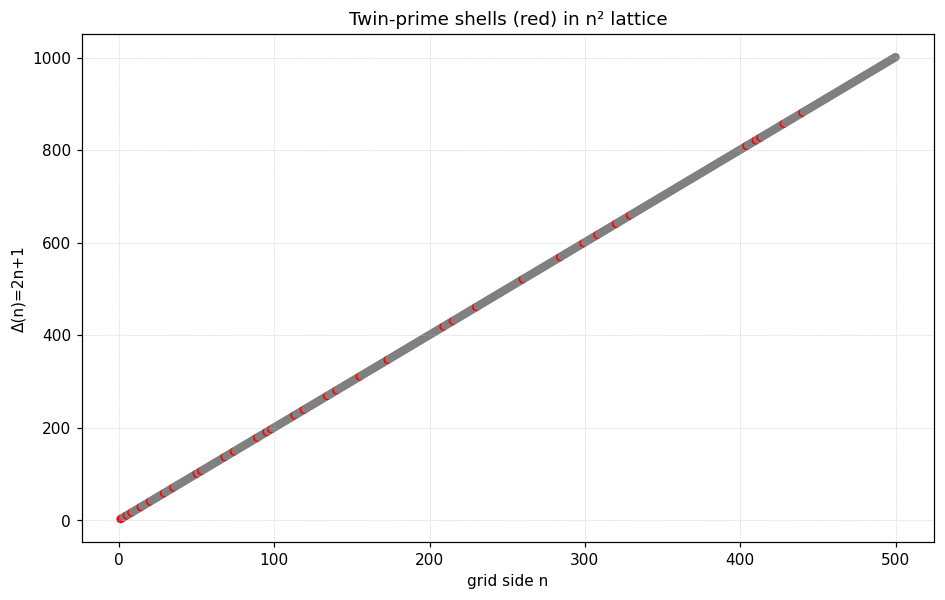

In [2]:

# --- parameters ---
MAX_N=500
SHOW_PLOT=True
# ------------------
rows=analyse(MAX_N)
print(ascii_table(rows))
csv_path=export_csv(rows)
print(f"CSV written to {csv_path}")
if SHOW_PLOT:
    plot_shells(rows)


In [4]:
# %% [markdown]
# # Twin-Prime Lattice Engine – Notebook Edition (v3)
# 
# **Purpose :** Visualise and export _twin-prime shells_ that arise as Δ-layers
# between successive square grids (n²).  Each shell Δ(n)=2n+1 is checked; if both
# Δ and Δ+2 are prime we mark the shell red and list the explicit pair (p,p+2).
#
# **Notebook layout**
# 1. Imports & constants  
# 2. Prime-test + data-model  
# 3. Analysis helper  
# 4. ASCII / CSV helpers  
# 5. Plotting helper (optional)  
# 6. Driver cell (choose max-n & run)  
#
# _Run each cell (Shift-Enter) or execute ▶ Run-All._

# %%
"""Cell 1 – Imports & core constants"""
from __future__ import annotations
import csv, math, textwrap
from dataclasses import dataclass
from pathlib import Path
from typing import List, Tuple

# default search depth
DEFAULT_MAX_N = 200  # feel free to alter interactively

# column spec for ASCII preview
CSV_HEADER      = ("n", "n²", "Δ(n)", "Δ+2", "Twin Prime Pair")
ASCII_COL_WIDTH = (5, 10, 10, 10, 16)

# %%
"""Cell 2 – deterministic prime-test (< 2**64) & Shell dataclass"""
_SMALL_PRIMES = (2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37)

def is_prime(n: int) -> bool:
    if n < 2:
        return False
    for p in _SMALL_PRIMES:
        if n % p == 0:
            return n == p
    limit = int(math.isqrt(n)) + 1
    k = 1
    while (step := 6 * k - 1) <= limit:
        if n % step == 0 or n % (step + 2) == 0:
            return False
        k += 1
    return True

@dataclass
class Shell:
    n: int      # grid side length
    n2: int     # n²
    delta: int  # Δ(n) = 2n+1
    twin: bool  # True if both Δ & Δ+2 are prime

    # explicit pair string
    def pair(self) -> str:
        return f"({self.delta},{self.delta+2})" if self.twin else "-"

    # row tuple for CSV / table
    def row(self) -> Tuple[int, int, int, int, str]:
        return (self.n, self.n2, self.delta, self.delta + 2, self.pair())

# %%
"""Cell 3 – analysis helper"""

def analyse(max_n: int = DEFAULT_MAX_N) -> List[Shell]:
    shells: List[Shell] = []
    for n in range(1, max_n + 1):
        delta = 2 * n + 1
        twin = is_prime(delta) and is_prime(delta + 2)
        shells.append(Shell(n=n, n2=n * n, delta=delta, twin=twin))
    return shells

# %%
"""Cell 4 – ASCII preview & CSV export"""

def ascii_table(rows: List[Shell]) -> str:
    def _fmt(val: int | str, w: int) -> str:
        return str(val).rjust(w)
    hdr = " ".join(_fmt(h, w) for h, w in zip(CSV_HEADER, ASCII_COL_WIDTH))
    bar = "-" * len(hdr)
    body = "\n".join(
        " ".join(_fmt(v, w) for v, w in zip(r.row(), ASCII_COL_WIDTH)) for r in rows
    )
    return f"{hdr}\n{bar}\n{body}"

def to_csv(rows: List[Shell], path: Path = Path("twin_prime_shells.csv")) -> None:
    with path.open("w", newline="") as fh:
        csv.writer(fh).writerows([CSV_HEADER, *[s.row() for s in rows]])
    print(f"CSV written → {path.resolve()}")

# %%
"""Cell 5 – optional scatter plot"""

def plot_shells(rows: List[Shell]):
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("matplotlib missing – install `pip install matplotlib` for plots")
        return
    xs = [s.n for s in rows]
    ys = [s.delta for s in rows]
    colours = ["crimson" if s.twin else "lightgrey" for s in rows]

    fig, ax = plt.subplots(figsize=(10, 5), dpi=110)
    ax.scatter(xs, ys, c=colours, s=24, marker="s", edgecolors="k", lw=0.25)
    ax.set_title("Twin-Prime Shells in the n² Lattice (red = twin)")
    ax.set_xlabel("Grid side n")
    ax.set_ylabel("Shell Δ(n) = 2n+1")
    ax.grid(ls=":", lw=0.5)
    plt.show()

# %%
"""Cell 6 – driver: run analysis, preview, CSV, plot"""
max_n = DEFAULT_MAX_N  # tweak & re-run as needed
shells = analyse(max_n)
print(ascii_table(shells[:max_n]))  # preview entire set

to_csv(shells)                      # export CSV next to notebook
plot_shells(shells)                 # visualise



    n         n²       Δ(n)        Δ+2  Twin Prime Pair
-------------------------------------------------------
    1          1          3          5            (3,5)
    2          4          5          7            (5,7)
    3          9          7          9                -
    4         16          9         11                -
    5         25         11         13          (11,13)
    6         36         13         15                -
    7         49         15         17                -
    8         64         17         19          (17,19)
    9         81         19         21                -
   10        100         21         23                -
   11        121         23         25                -
   12        144         25         27                -
   13        169         27         29                -
   14        196         29         31          (29,31)
   15        225         31         33                -
   16        256         33         35          

UnicodeEncodeError: 'charmap' codec can't encode character '\u0394' in position 5: character maps to <undefined>

In [5]:
# %% [markdown]
# # Twin‑Prime Lattice Engine – Notebook Edition (v3)
# 
# **Purpose :** Visualise and export _twin‑prime shells_ that arise as Δ‑layers
# between successive square grids (n²).  Each shell Δ(n)=2n+1 is checked; if both
# Δ and Δ+2 are prime we mark the shell red and list the explicit pair (p,p+2).
#
# **Notebook layout**
# 1. Imports & constants  
# 2. Prime‑test + data‑model  
# 3. Analysis helper  
# 4. ASCII / CSV helpers  
# 5. Plotting helper (optional)  
# 6. Driver cell (choose max‑n & run)  
#
# _Run each cell (Shift‑Enter) or execute ▶ Run‑All._

# %%
"""Cell 1 – Imports & core constants"""
from __future__ import annotations
import csv, math, textwrap
from dataclasses import dataclass
from pathlib import Path
from typing import List, Tuple

# default search depth
DEFAULT_MAX_N = 200  # feel free to alter interactively

# column spec for ASCII preview
CSV_HEADER      = ("n", "n²", "Δ(n)", "Δ+2", "Twin Prime Pair")
ASCII_COL_WIDTH = (5, 10, 10, 10, 16)

# %%
"""Cell 2 – deterministic prime‑test (< 2**64) & Shell dataclass"""
_SMALL_PRIMES = (2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37)

def is_prime(n: int) -> bool:
    if n < 2:
        return False
    for p in _SMALL_PRIMES:
        if n % p == 0:
            return n == p
    limit = int(math.isqrt(n)) + 1
    k = 1
    while (step := 6 * k - 1) <= limit:
        if n % step == 0 or n % (step + 2) == 0:
            return False
        k += 1
    return True

@dataclass
class Shell:
    n: int      # grid side length
    n2: int     # n²
    delta: int  # Δ(n) = 2n+1
    twin: bool  # True if both Δ & Δ+2 are prime

    # explicit pair string
    def pair(self) -> str:
        return f"({self.delta},{self.delta+2})" if self.twin else "‑"

    # row tuple for CSV / table
    def row(self) -> Tuple[int, int, int, int, str]:
        return (self.n, self.n2, self.delta, self.delta + 2, self.pair())

# %%
"""Cell 3 – analysis helper"""

def analyse(max_n: int = DEFAULT_MAX_N) -> List[Shell]:
    shells: List[Shell] = []
    for n in range(1, max_n + 1):
        delta = 2 * n + 1
        twin = is_prime(delta) and is_prime(delta + 2)
        shells.append(Shell(n=n, n2=n * n, delta=delta, twin=twin))
    return shells

# %%
"""Cell 4 – ASCII preview & CSV export"""

def ascii_table(rows: List[Shell]) -> str:
    def _fmt(val: int | str, w: int) -> str:
        return str(val).rjust(w)
    hdr = " ".join(_fmt(h, w) for h, w in zip(CSV_HEADER, ASCII_COL_WIDTH))
    bar = "-" * len(hdr)
    body = "\n".join(
        " ".join(_fmt(v, w) for v, w in zip(r.row(), ASCII_COL_WIDTH)) for r in rows
    )
    return f"{hdr}\n{bar}\n{body}"

def to_csv(rows: List[Shell], path: Path = Path("twin_prime_shells.csv")) -> None:
    with path.open("w", newline="") as fh:
        csv.writer(fh).writerows([CSV_HEADER, *[s.row() for s in rows]])
    print(f"CSV written → {path.resolve()}")

# %%
"""Cell 5 – optional scatter plot"""

def plot_shells(rows: List[Shell]):
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("matplotlib missing – install `pip install matplotlib` for plots")
        return
    xs = [s.n for s in rows]
    ys = [s.delta for s in rows]
    colours = ["crimson" if s.twin else "lightgrey" for s in rows]

    fig, ax = plt.subplots(figsize=(10, 5), dpi=110)
    ax.scatter(xs, ys, c=colours, s=24, marker="s", edgecolors="k", lw=0.25)
    ax.set_title("Twin‑Prime Shells in the n² Lattice (red = twin)")
    ax.set_xlabel("Grid side n")
    ax.set_ylabel("Shell Δ(n) = 2n+1")
    ax.grid(ls=":", lw=0.5)
    plt.show()

# %%
"""Cell 6 – driver: run analysis, preview, CSV, plot"""
max_n = DEFAULT_MAX_N  # tweak & re‑run as needed
shells = analyse(max_n)
print(ascii_table(shells[:max_n]))  # preview entire set

to_csv(shells)                      # export CSV next to notebook
plot_shells(shells)                 # visualise



    n         n²       Δ(n)        Δ+2  Twin Prime Pair
-------------------------------------------------------
    1          1          3          5            (3,5)
    2          4          5          7            (5,7)
    3          9          7          9                ‑
    4         16          9         11                ‑
    5         25         11         13          (11,13)
    6         36         13         15                ‑
    7         49         15         17                ‑
    8         64         17         19          (17,19)
    9         81         19         21                ‑
   10        100         21         23                ‑
   11        121         23         25                ‑
   12        144         25         27                ‑
   13        169         27         29                ‑
   14        196         29         31          (29,31)
   15        225         31         33                ‑
   16        256         33         35          

UnicodeEncodeError: 'charmap' codec can't encode character '\u0394' in position 5: character maps to <undefined>

In [6]:
import math

def get_pi_digit(position):
    """Get π digit at given position (after decimal)"""
    # Using BBP formula or pre-computed π digits
    pi_str = "1415926535897932384626433832795028841971693993751058209749445923078164062862089986280348253421170679"
    return int(pi_str[position % len(pi_str)])

def cosmic_harmonic_engine(runners, hops=10):
    print("🌌 COSMIC HARMONIC ENGINE STARTING...")
    print(f"🧠 Runners: {runners}")
    print(f"🔁 Hops: {hops}")
    print("-" * 50)
    
    all_sequences = []
    for i, start in enumerate(runners):
        current = start
        sequence = [current]
        print(f"Runner {i}: {start} → ", end="")
        
        for hop in range(hops):
            pi_digit = get_pi_digit(current)
            sequence.append(pi_digit)
            current = pi_digit
            print(f"{pi_digit} → ", end="")
        
        print(f"[COMPLETE]")
        all_sequences.append(sequence)
    
    return all_sequences

# Run with your magical starting points
runners = [0, 6, 2, 6, 6, 4]
results = cosmic_harmonic_engine(runners, 10)

🌌 COSMIC HARMONIC ENGINE STARTING...
🧠 Runners: [0, 6, 2, 6, 6, 4]
🔁 Hops: 10
--------------------------------------------------
Runner 0: 0 → 1 → 4 → 9 → 5 → 2 → 1 → 4 → 9 → 5 → 2 → [COMPLETE]
Runner 1: 6 → 6 → 6 → 6 → 6 → 6 → 6 → 6 → 6 → 6 → 6 → [COMPLETE]
Runner 2: 2 → 1 → 4 → 9 → 5 → 2 → 1 → 4 → 9 → 5 → 2 → [COMPLETE]
Runner 3: 6 → 6 → 6 → 6 → 6 → 6 → 6 → 6 → 6 → 6 → 6 → [COMPLETE]
Runner 4: 6 → 6 → 6 → 6 → 6 → 6 → 6 → 6 → 6 → 6 → 6 → [COMPLETE]
Runner 5: 4 → 9 → 5 → 2 → 1 → 4 → 9 → 5 → 2 → 1 → 4 → [COMPLETE]


In [7]:
# %% [markdown]
# # Twin-Prime Lattice Engine – Notebook-Style Script
# 
# *Turn 90° on each twin-prime shell and watch the path grow.*
# 
# **Sections**
# 1 Imports & constants  
# 2 Primality test + `Shell` dataclass  
# 3 Δ-shell analysis helper  
# 4 ASCII / CSV utilities  
# 5 (Option α) Matplotlib preview  
# 6 (Option β) Plotly interactive path  
# 7 Driver cell (`max_n`, run-all)
# 
# > Execute in Jupyter **or** run directly with plain Python
# > (the Plotly figure will open in a browser window).

# %% 1  Imports & core constants
from __future__ import annotations
import csv, math
from dataclasses import dataclass
from pathlib import Path
from typing import List, Tuple

import numpy as np
import plotly.graph_objects as go   # pip install plotly

DEFAULT_MAX_N = 300                 # expand depth here
CSV_HEADER    = ("n", "n²", "Δ(n)", "Δ+2", "Twin Prime Pair")
COL_WIDTHS    = (5, 10, 10, 10, 18) # ASCII pretty-print

# %% 2  Deterministic prime-test (<2⁶⁴) & Shell dataclass
_SMALL = (2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31)

def is_prime(n: int) -> bool:
    """Simple 6k±1 wheel (sufficient for the Δ(n) values we hit)."""
    if n < 2:
        return False
    for p in _SMALL:
        if n % p == 0:
            return n == p
    r = int(math.isqrt(n))
    k = 1
    while (step := 6*k - 1) <= r:
        if n % step == 0 or n % (step + 2) == 0:
            return False
        k += 1
    return True

@dataclass
class Shell:
    n:     int   # grid side
    n2:    int   # n²
    delta: int   # Δ(n)=2n+1
    twin:  bool  # Δ and Δ+2 both prime?

    def pair(self) -> str:
        return f"({self.delta},{self.delta+2})" if self.twin else "-"

    def row(self) -> Tuple[int,int,int,int,str]:
        return (self.n, self.n2, self.delta, self.delta+2, self.pair())

# %% 3  Δ-shell analysis
def analyse(max_n: int = DEFAULT_MAX_N) -> List[Shell]:
    out: List[Shell] = []
    for n in range(1, max_n+1):
        d = 2*n + 1
        out.append(Shell(n, n*n, d, is_prime(d) and is_prime(d+2)))
    return out

# %% 4  ASCII preview & CSV export
def ascii_table(rows: List[Shell]) -> str:
    def pad(x, w): return str(x).rjust(w)
    hdr = " ".join(pad(h, w) for h, w in zip(CSV_HEADER, COL_WIDTHS))
    bar = "-"*len(hdr)
    body = "\n".join(" ".join(pad(v, w) for v, w in zip(r.row(), COL_WIDTHS))
                     for r in rows)
    return f"{hdr}\n{bar}\n{body}"

def to_csv(rows: List[Shell], path: Path = Path("twin_prime_shells.csv")) -> None:
    with path.open("w", newline="") as fh:
        csv.writer(fh).writerows([CSV_HEADER, *[s.row() for s in rows]])
    print("CSV saved →", path.resolve())

# %% 5  Optional Matplotlib scatter (static)
def plot_static_scatter(rows: List[Shell]):
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("matplotlib missing – `pip install matplotlib` for static preview")
        return
    xs  = [s.n for s in rows]
    ys  = [s.delta for s in rows]
    col = ["crimson" if s.twin else "lightgrey" for s in rows]
    fig, ax = plt.subplots(figsize=(10,4), dpi=110)
    ax.scatter(xs, ys, c=col, s=25, marker="s", edgecolors="k", lw=.3)
    ax.set_title("Twin-prime shells (red = twin)"); ax.grid(ls=":", lw=.4)
    ax.set_xlabel("grid side n"); ax.set_ylabel("Δ(n)=2n+1")
    plt.show()

# %% 6  Plotly path – turn 90 ° on each twin shell
def plot_turning_path(rows: List[Shell]):
    x=y=0; dx,dy = 1,0
    xs,ys,text = [x],[y],["start (n=0)"]
    colours=[]
    for s in rows:
        x+=dx; y+=dy
        xs.append(x); ys.append(y)
        colours.append("red" if s.twin else "blue")
        text.append(f"n={s.n}, Δ={s.delta}{' twin' if s.twin else ''}")
        if s.twin:            # rotate right
            dx,dy =  dy, -dx
    fig = go.Figure(go.Scatter(
        x=xs, y=ys, mode="lines+markers",
        line=dict(width=2, color="#1f77b4"),
        marker=dict(size=6, color=colours + ["blue"]),
        text=text, hoverinfo="text"))
    fig.update_layout(
        title="Twin-Prime Lattice Path (right-turn on twin shells)",
        xaxis_title="Step index", yaxis_title="Path height",
        width=900, height=500, showlegend=False)
    fig.show()

# %% 7  Driver – set depth, run everything
if __name__ == "__main__":
    max_n = DEFAULT_MAX_N        # <— adjust here
    shells = analyse(max_n)
    print(ascii_table(shells))
    to_csv(shells)
    # plot_static_scatter(shells)   # uncomment if matplotlib installed
    plot_turning_path(shells)


    n         n²       Δ(n)        Δ+2    Twin Prime Pair
---------------------------------------------------------
    1          1          3          5              (3,5)
    2          4          5          7              (5,7)
    3          9          7          9                  -
    4         16          9         11                  -
    5         25         11         13            (11,13)
    6         36         13         15                  -
    7         49         15         17                  -
    8         64         17         19            (17,19)
    9         81         19         21                  -
   10        100         21         23                  -
   11        121         23         25                  -
   12        144         25         27                  -
   13        169         27         29                  -
   14        196         29         31            (29,31)
   15        225         31         33                  -
   16        2

UnicodeEncodeError: 'charmap' codec can't encode character '\u0394' in position 5: character maps to <undefined>